Libraries

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

Paths

In [2]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR = "data/results/models"

# Join Results

## Queries

In [3]:
queries_rows = []
for file_name in os.listdir(QUERIES_DIR):
    if file_name.endswith(".json"):
        file_path = os.path.join(QUERIES_DIR, file_name)
        with open(file_path, "r") as f:
            data = json.load(f)
        for run in data.get("runs", []):
            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),
                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }
            for metric in run.get("metrics", []):
                row = {**base_info, 'query_description': metric.get("Query Description"), 'api_time_s': metric.get("API Time (s)"), 'sql_time_s': metric.get("SQL Time (s)"), 'time_delta': metric.get("Time Delta (SQL - API)")}
                queries_rows.append(row)
df_queries = pd.DataFrame(queries_rows)

## Models

In [4]:
models_rows = []
for file_name in os.listdir(MODELS_DIR):
    if file_name.endswith(".json"):
        file_path = os.path.join(MODELS_DIR, file_name)
        with open(file_path, "r") as f:
            data = json.load(f)
        for run in data.get("runs", []):
            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),
                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }
            for result in run.get("model_results", []):
                metrics = result.get("metrics", {})
                row = {**base_info, 'model_name': result.get("model_name"), 'target': result.get("target"), 'task_type': result.get("task_type"), 'rmse': metrics.get("rmse"), 'r2': metrics.get("r2"), 'mae': metrics.get("mae"), 'mse': metrics.get("mse"), 'execution_time_seconds': result.get("execution_time_seconds")}
                models_rows.append(row)
df_models = pd.DataFrame(models_rows)

## Query Performance Plots

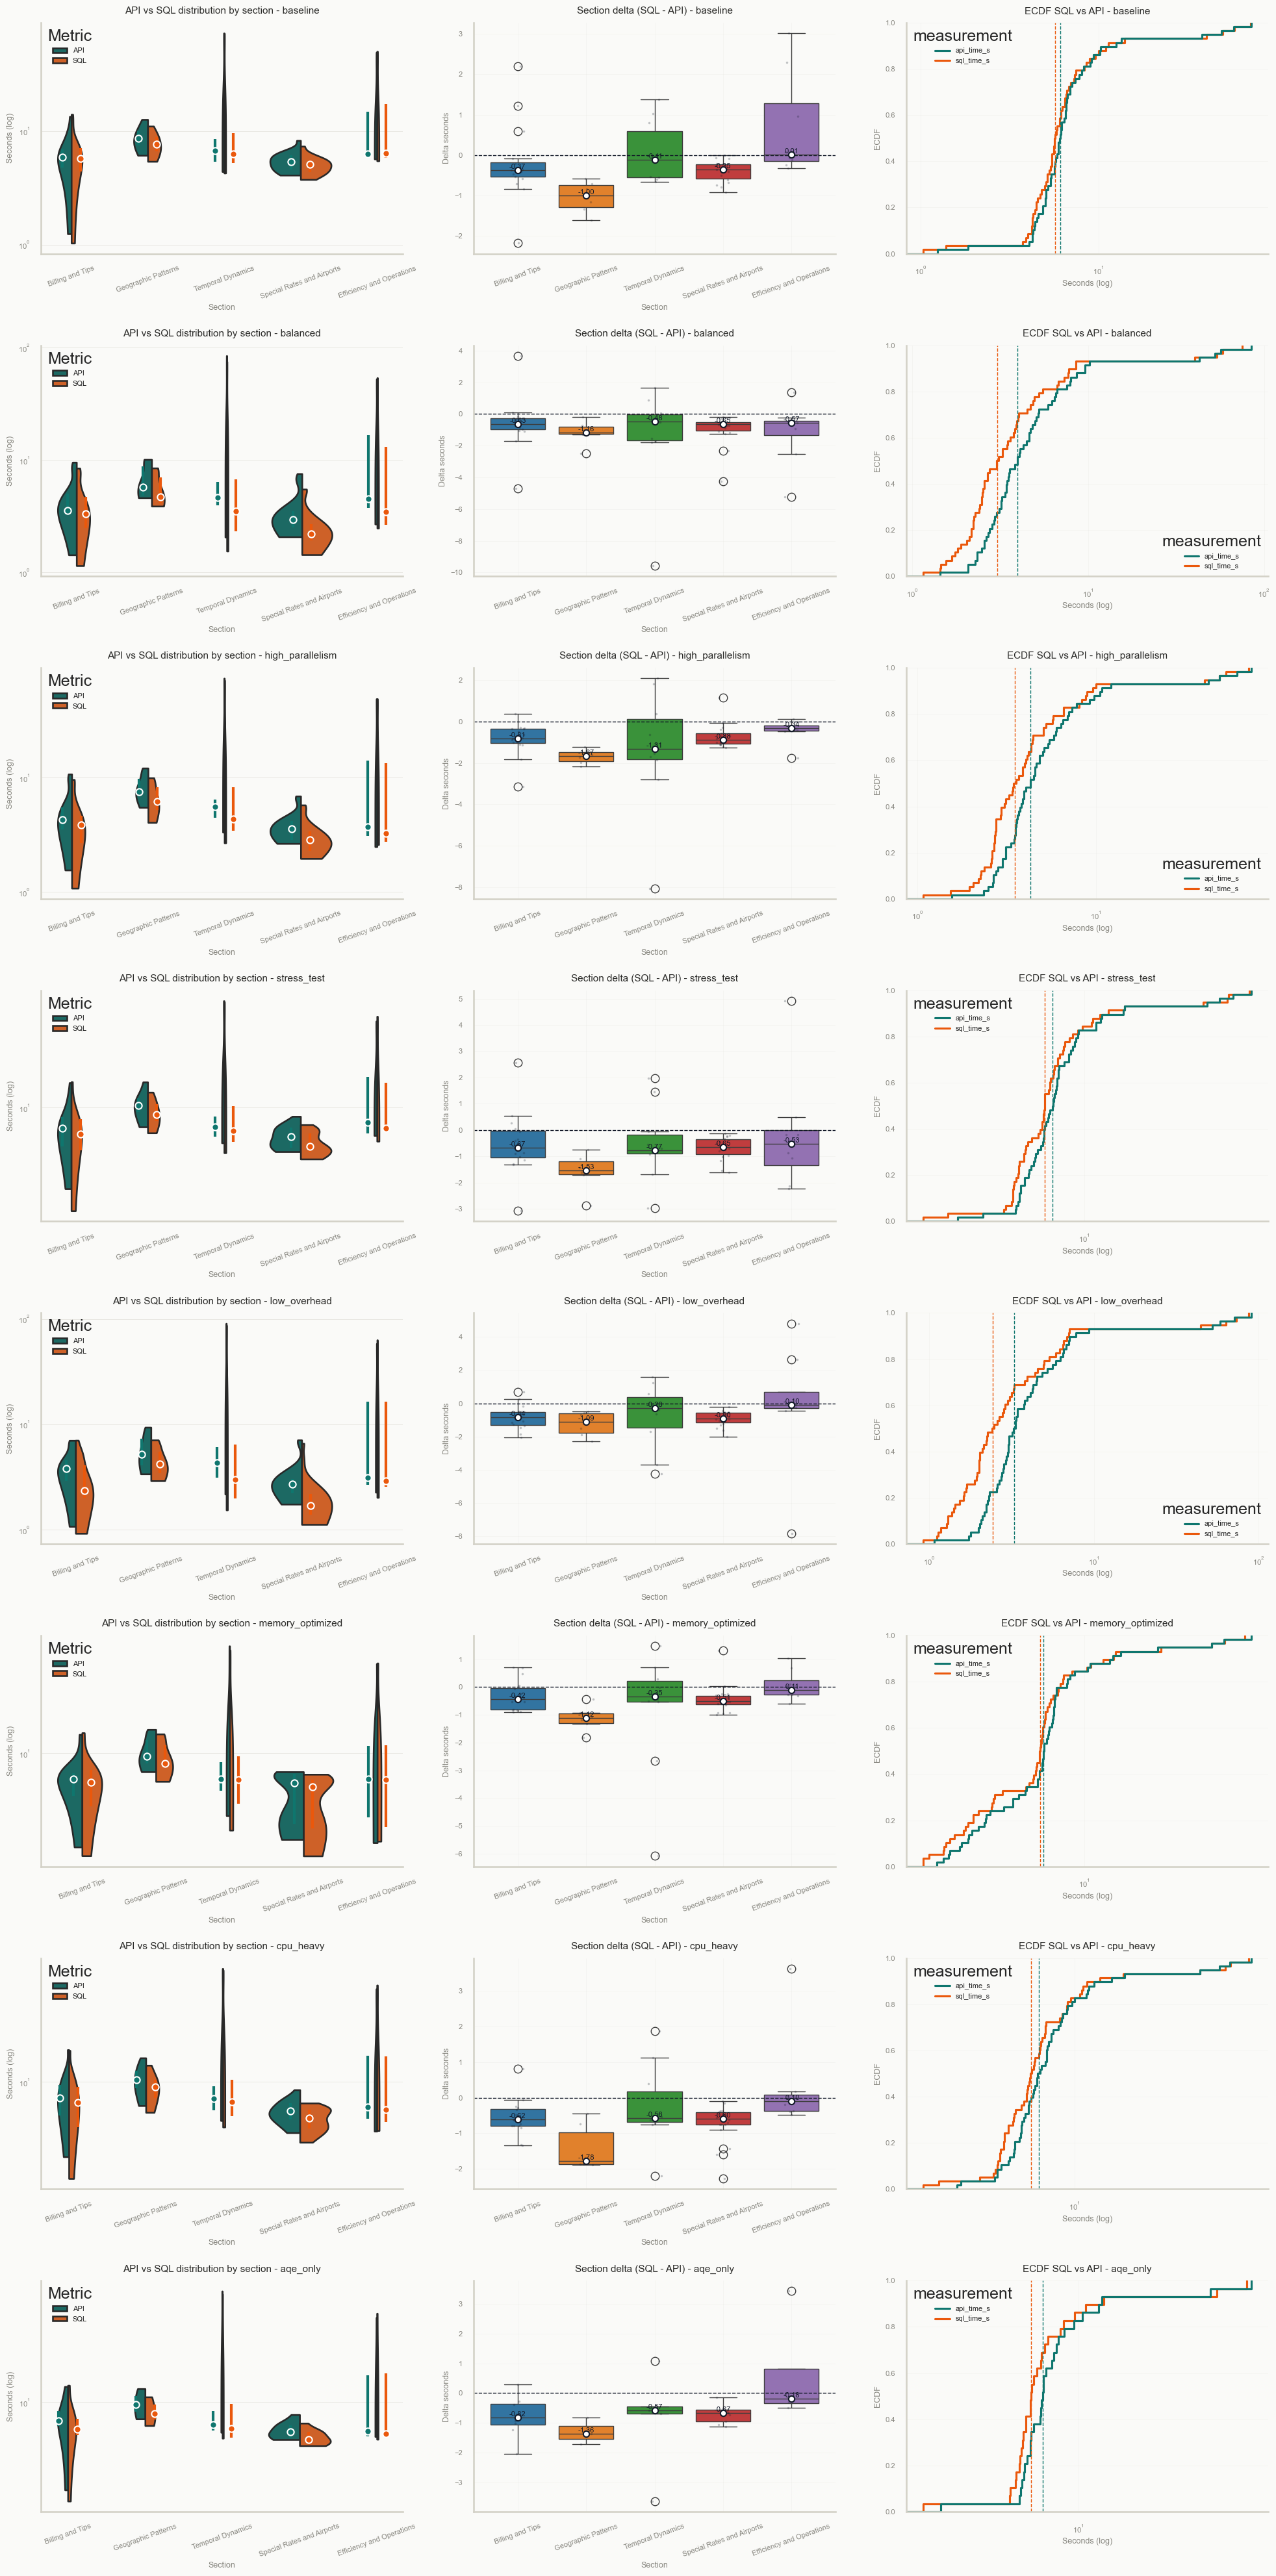

In [35]:
if df_queries.empty:
    raise ValueError("No query data was loaded.")
section_labels = {'Q1': 'Billing and Tips', 'Q2': 'Geographic Patterns', 'Q3': 'Temporal Dynamics', 'Q4': 'Special Rates and Airports', 'Q5': 'Efficiency and Operations'}
section_order = list(section_labels.values())
palette = dict(zip(section_order, sns.color_palette('tab10', n_colors=len(section_order))))
metric_colors = {'api_time_s': '#0f766e', 'sql_time_s': '#ea580c'}
qdf = df_queries.copy()
qdf['query_group'] = qdf['query_description'].str.extract(r'^(Q\d)')[0]
qdf['section_name'] = qdf['query_group'].map(section_labels)
qdf['section_name'] = pd.Categorical(qdf['section_name'], categories=section_order, ordered=True)
qdf['time_delta_s'] = qdf['sql_time_s'] - qdf['api_time_s']
qdf['time_ratio'] = qdf['sql_time_s'].div(qdf['api_time_s'].replace(0, pd.NA))
qdf['speedup_pct'] = (qdf['api_time_s'] - qdf['sql_time_s']).div(qdf['api_time_s'].replace(0, pd.NA)) * 100

section_summary = (
    qdf.groupby(['section_name', 'spark_mode'], as_index=False, observed=True)
    .agg(query_count=('query_description', 'count'), median_api_s=('api_time_s', 'median'), median_sql_s=('sql_time_s', 'median'), median_delta_s=('time_delta_s', 'median'), median_ratio=('time_ratio', 'median'), median_speedup_pct=('speedup_pct', 'median'))
    .sort_values(['section_name', 'spark_mode'])
)
section_profile = (
    qdf.groupby('section_name', as_index=False, observed=True)
    .agg(query_count=('query_description', 'count'), median_api_s=('api_time_s', 'median'), median_sql_s=('sql_time_s', 'median'), median_delta_s=('time_delta_s', 'median'), median_speedup_pct=('speedup_pct', 'median'))
    .sort_values('section_name')
)
per_query = (
    qdf.groupby(['query_description', 'section_name'], as_index=False, observed=True)
    .agg(runs=('query_description', 'count'), median_api_s=('api_time_s', 'median'), median_sql_s=('sql_time_s', 'median'), median_delta_s=('time_delta_s', 'median'))
    .assign(median_speedup_pct=lambda df: (df['median_api_s'] - df['median_sql_s']).div(df['median_api_s'].replace(0, pd.NA)) * 100)
    .sort_values('median_delta_s', ascending=False)
)

spark_modes = qdf['spark_mode'].dropna().drop_duplicates().tolist()
fig, axes = plt.subplots(len(spark_modes), 3, figsize=(20, 5 * len(spark_modes)), squeeze=False)
for row_index, spark_mode in enumerate(spark_modes):
    mode_df = qdf[qdf['spark_mode'] == spark_mode]
    if mode_df.empty:
        continue
    left_ax = axes[row_index, 0]
    mid_ax = axes[row_index, 1]
    right_ax = axes[row_index, 2]
    melt = mode_df.melt(id_vars=['section_name'], value_vars=['api_time_s','sql_time_s'], var_name='measurement', value_name='seconds')
    sns.violinplot(data=melt, x='section_name', y='seconds', hue='measurement', split=True, order=section_order, palette=[metric_colors['api_time_s'], metric_colors['sql_time_s']], inner=None, cut=0, ax=left_ax)
    for i, sec in enumerate(section_order):
        api_vals = melt.loc[(melt['section_name'] == sec) & (melt['measurement'] == 'api_time_s'), 'seconds'].dropna()
        sql_vals = melt.loc[(melt['section_name'] == sec) & (melt['measurement'] == 'sql_time_s'), 'seconds'].dropna()
        if not api_vals.empty:
            left_ax.scatter(i - 0.12, api_vals.median(), color=metric_colors['api_time_s'], edgecolors='white', s=55, zorder=10)
            left_ax.vlines(i - 0.12, api_vals.quantile(0.25), api_vals.quantile(0.75), color=metric_colors['api_time_s'], linewidth=3, zorder=9)
        if not sql_vals.empty:
            left_ax.scatter(i + 0.12, sql_vals.median(), color=metric_colors['sql_time_s'], edgecolors='white', s=55, zorder=10)
            left_ax.vlines(i + 0.12, sql_vals.quantile(0.25), sql_vals.quantile(0.75), color=metric_colors['sql_time_s'], linewidth=3, zorder=9)
    left_ax.set_yscale('log')
    left_ax.set_title(f'API vs SQL distribution by section - {spark_mode}')
    left_ax.set_xlabel('Section')
    left_ax.set_ylabel('Seconds (log)')
    left_ax.tick_params(axis='x', rotation=20)
    left_ax.legend(title='Metric', labels=['API', 'SQL'])
    sns.boxplot(data=mode_df, x='section_name', y='time_delta_s', hue='section_name', order=section_order, palette=palette, dodge=False, legend=False, ax=mid_ax)
    sns.stripplot(data=mode_df, x='section_name', y='time_delta_s', order=section_order, color='#111827', alpha=0.25, size=2.5, ax=mid_ax)
    mid_ax.axhline(0, color='#111827', linestyle='--', linewidth=1)
    mid_ax.set_title(f'Section delta (SQL - API) - {spark_mode}')
    mid_ax.set_xlabel('Section')
    mid_ax.set_ylabel('Delta seconds')
    mid_ax.tick_params(axis='x', rotation=20)
    for i, sec in enumerate(section_order):
        vals = mode_df.loc[mode_df['section_name'] == sec, 'time_delta_s'].dropna()
        if vals.empty:
            continue
        mid_ax.scatter(i, vals.median(), color='#ffffff', edgecolors='#111827', s=45, zorder=10)
        mid_ax.text(i, vals.median(), f'{vals.median():.2f}', ha='center', va='bottom', fontsize=8, color='#111827')
    mid_ax.grid(True, alpha=0.2)
    sns.ecdfplot(data=melt, x='seconds', hue='measurement', ax=right_ax, palette=[metric_colors['api_time_s'], metric_colors['sql_time_s']])
    right_ax.set_xscale('log')
    right_ax.set_title(f'ECDF SQL vs API - {spark_mode}')
    right_ax.set_xlabel('Seconds (log)')
    right_ax.set_ylabel('ECDF')
    right_ax.axvline(mode_df['api_time_s'].median(), color=metric_colors['api_time_s'], linestyle='--', linewidth=1)
    right_ax.axvline(mode_df['sql_time_s'].median(), color=metric_colors['sql_time_s'], linestyle='--', linewidth=1)
    right_ax.grid(True, alpha=0.2)
plt.tight_layout()

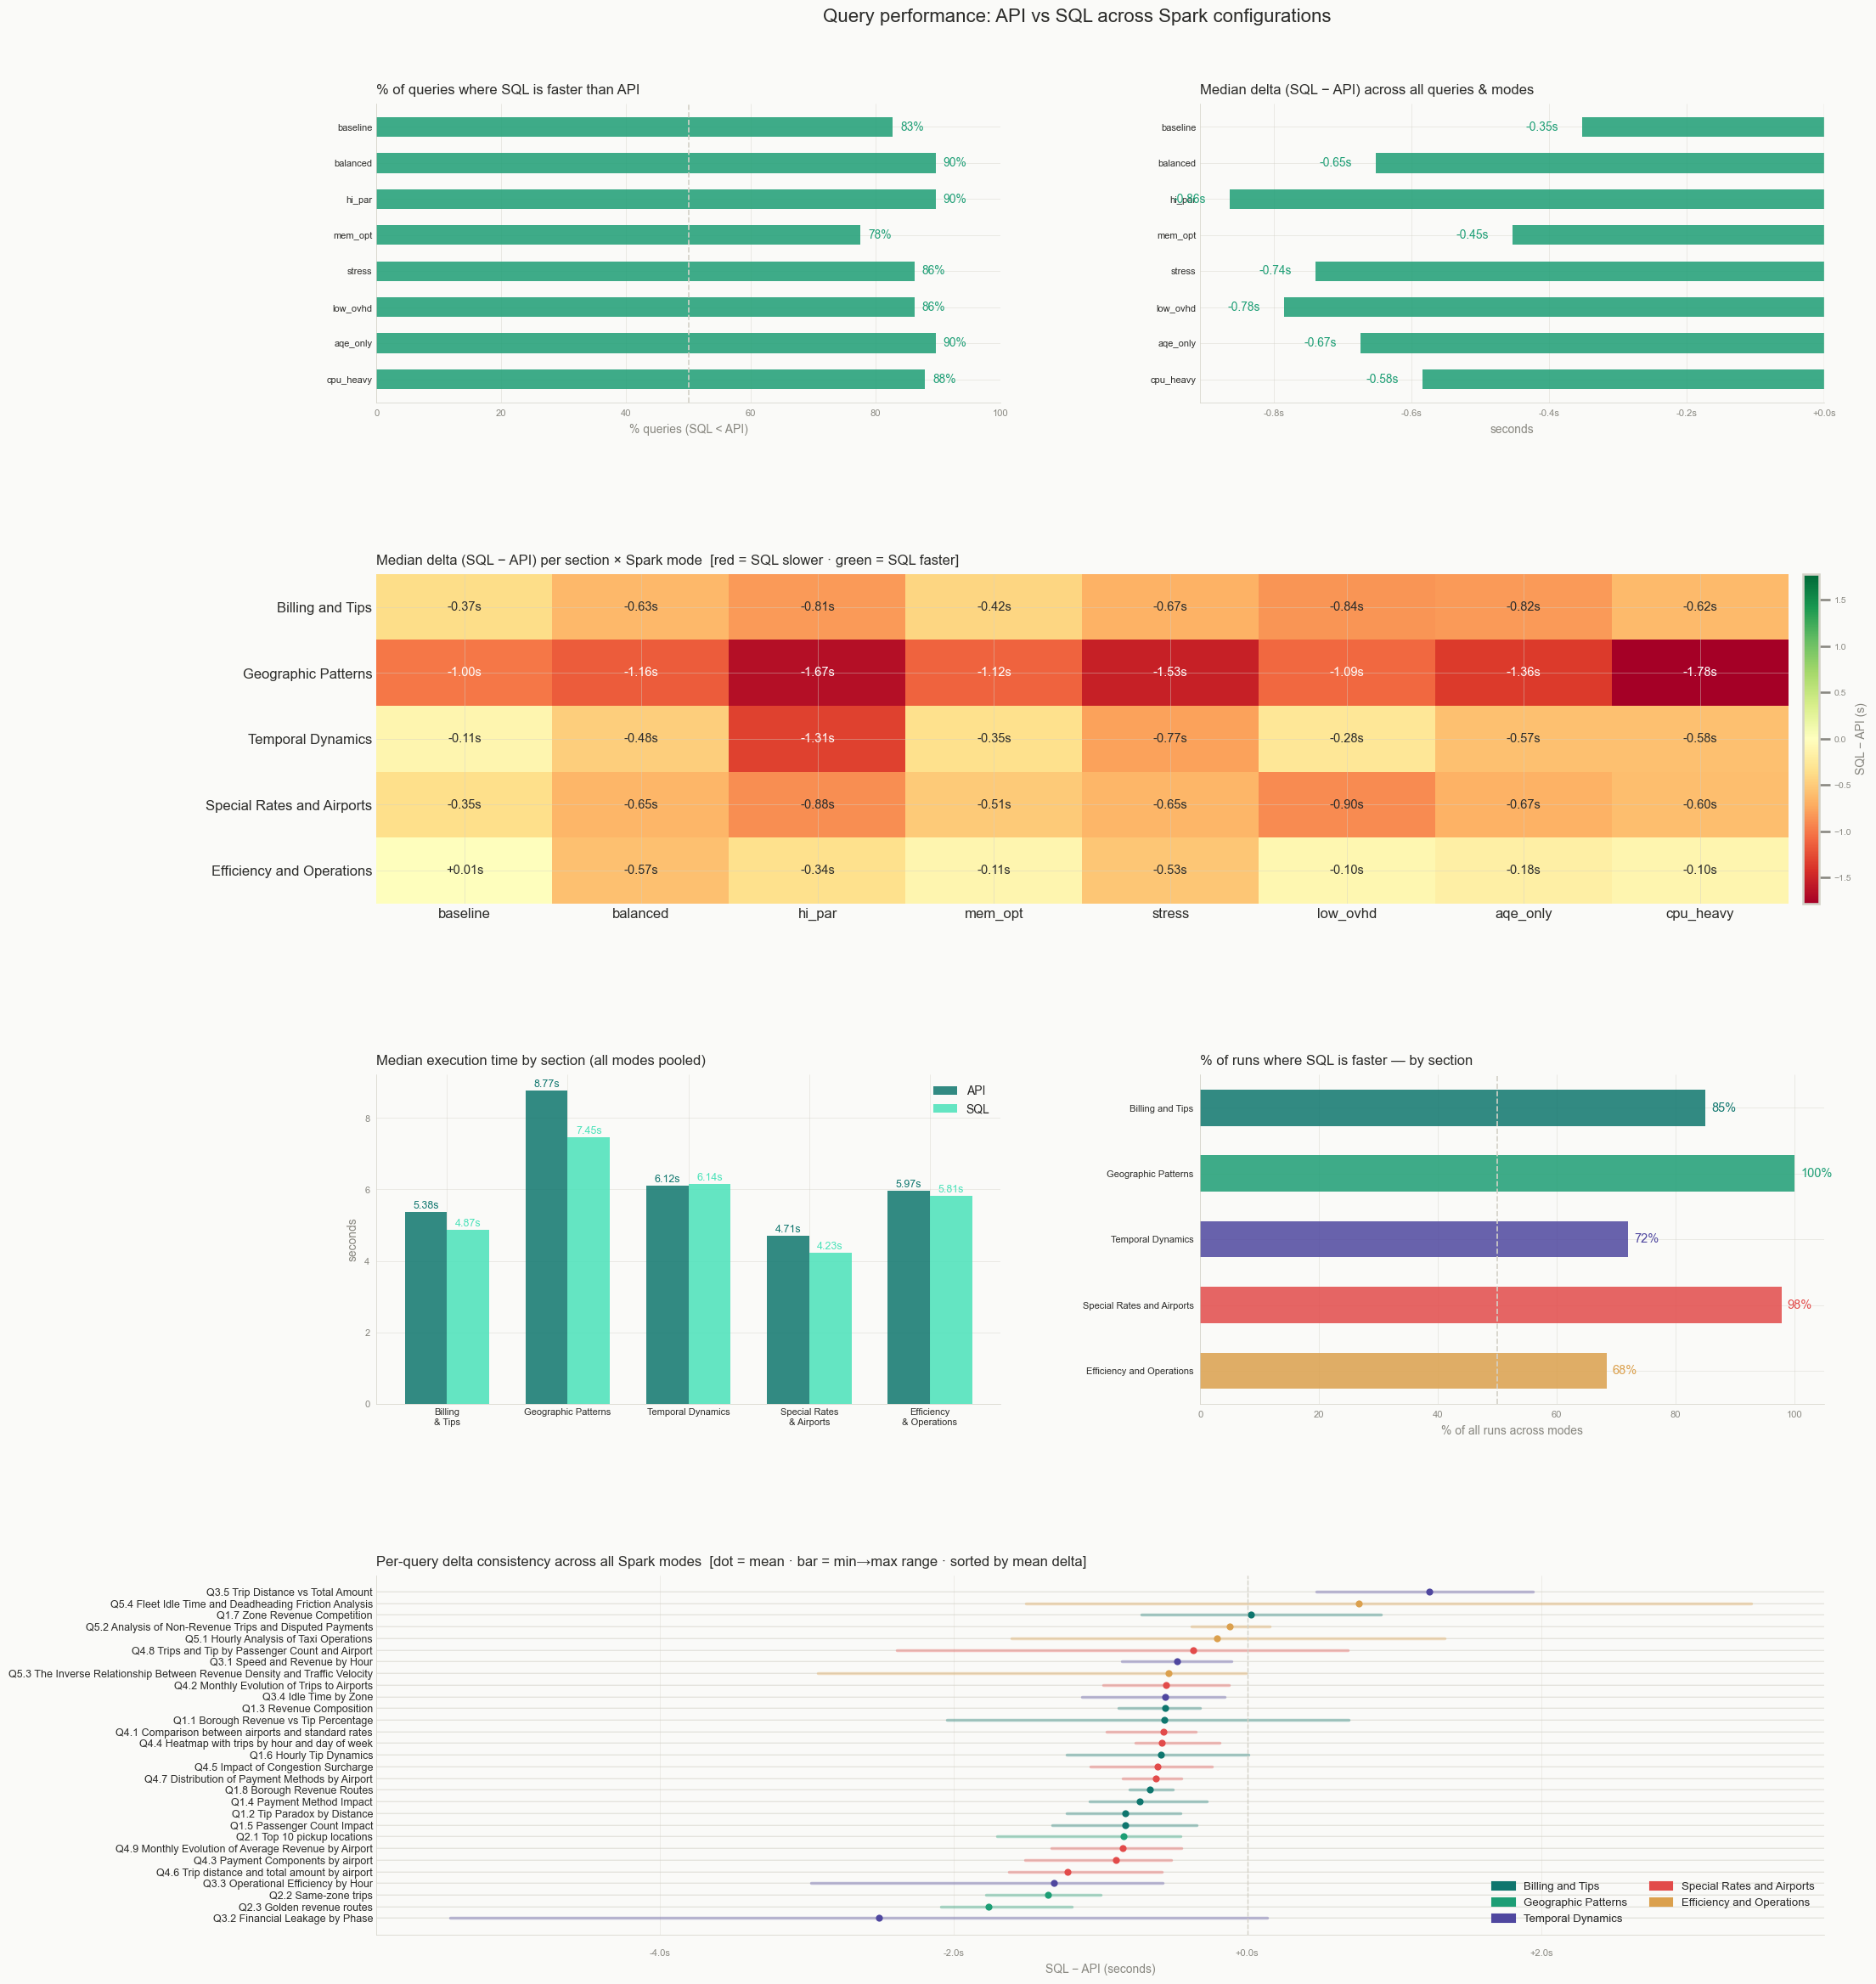

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

BG      = "#FAFAF8"
SURFACE = "#F1EFE8"
BORDER  = "#D3D1C7"
TEXT    = "#2C2C2A"
TEXT_M  = "#888780"
API_C   = "#0f766e"
SQL_C   = "#4AE2B9"
RED     = "#E24B4A"
GREEN   = "#1D9E75"
PURPLE  = "#7F77DD"
AMBER   = "#BA7517"

SEC_COLORS = {
    "Billing and Tips":          "#0f766e",
    "Geographic Patterns":       "#1D9E75",
    "Temporal Dynamics":         "#4F479F",
    "Special Rates and Airports":"#E24B4A",
    "Efficiency and Operations": "#DBA04D",
}

MODE_ORDER = [
    "baseline", "balanced", "high_parallelism", "memory_optimized",
    "stress_test", "low_overhead", "aqe_only", "cpu_heavy",
]
MODE_ORDER = [m for m in MODE_ORDER if m in qdf["spark_mode"].unique()]
SHORT = {
    "baseline":"baseline","balanced":"balanced",
    "high_parallelism":"hi_par","memory_optimized":"mem_opt",
    "stress_test":"stress","low_overhead":"low_ovhd",
    "aqe_only":"aqe_only","cpu_heavy":"cpu_heavy",
}

def style(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER); sp.set_linewidth(0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=8, length=2, color=BORDER)
    ax.set_title(title, fontsize=12, fontweight="medium", color=TEXT, pad=8, loc="left")
    if xlabel: ax.set_xlabel(xlabel, fontsize=10, color=TEXT_M, labelpad=5)
    if ylabel: ax.set_ylabel(ylabel, fontsize=10, color=TEXT_M, labelpad=5)
    ax.grid(color=BORDER, linewidth=0.4, alpha=0.7)

# ── pre-aggregate ─────────────────────────────────────────────────────────────
# per (section × mode): median delta and median times
sec_mode = (
    qdf.groupby(["section_name", "spark_mode"], observed=True)
    .agg(
        median_delta  = ("time_delta_s",  "median"),
        median_api    = ("api_time_s",    "median"),
        median_sql    = ("sql_time_s",    "median"),
        pct_sql_faster= ("time_delta_s",  lambda x: (x < 0).mean() * 100),
    )
    .reset_index()
)

# per (query × mode)
q_mode = (
    qdf.groupby(["query_description", "section_name", "spark_mode"], observed=True)
    .agg(median_delta=("time_delta_s", "median"),
         median_api  =("api_time_s",   "median"),
         median_sql  =("sql_time_s",   "median"))
    .reset_index()
)

# overall per mode
mode_agg = (
    qdf.groupby("spark_mode", observed=True)
    .agg(
        median_delta   = ("time_delta_s", "median"),
        pct_sql_faster = ("time_delta_s", lambda x: (x < 0).mean() * 100),
        median_api     = ("api_time_s",   "median"),
        median_sql     = ("sql_time_s",   "median"),
    )
    .reindex(MODE_ORDER)
)

# consistency: std of median delta across modes per query
q_consistency = (
    q_mode.groupby(["query_description", "section_name"], observed=True)
    .agg(
        mean_delta = ("median_delta", "mean"),
        std_delta  = ("median_delta", "std"),
        min_delta  = ("median_delta", "min"),
        max_delta  = ("median_delta", "max"),
    )
    .reset_index()
    .assign(delta_range=lambda d: d["max_delta"] - d["min_delta"])
    .sort_values("mean_delta")
)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 28), facecolor=BG)
fig.suptitle("Query performance: API vs SQL across Spark configurations",
             fontsize=16, fontweight="medium", color=TEXT, y=0.92)

gs = gridspec.GridSpec(
    4, 2, figure=fig,
    height_ratios=[1, 1.1, 1.1, 1.2],
    hspace=0.52, wspace=0.32,
)

# ── PANEL 1 (top-left): % of queries where SQL is faster, per mode ────────────
ax1 = fig.add_subplot(gs[0, 0])
pct = mode_agg["pct_sql_faster"].values
cols = [GREEN if p >= 50 else RED for p in pct]
bars = ax1.barh(range(len(MODE_ORDER)), pct, height=0.55,
                color=cols, alpha=0.85, zorder=2, linewidth=0)
ax1.axvline(50, color=BORDER, linewidth=1.2, linestyle="--", zorder=3)
for i, (p, m) in enumerate(zip(pct, MODE_ORDER)):
    ax1.text(p + 1.2, i, f"{p:.0f}%", va="center", fontsize=10,
             color=GREEN if p >= 50 else RED, fontweight="medium")
ax1.set_yticks(range(len(MODE_ORDER)))
ax1.set_yticklabels([SHORT[m] for m in MODE_ORDER], fontsize=10.5, color=TEXT)
ax1.set_xlim(0, 100)
ax1.invert_yaxis()
style(ax1, "% of queries where SQL is faster than API",
      xlabel="% queries (SQL < API)")
ax1.tick_params(axis="y", length=0)

# ── PANEL 2 (top-right): median delta per mode (overall) ──────────────────────
ax2 = fig.add_subplot(gs[0, 1])
deltas = mode_agg["median_delta"].values
cols2  = [RED if d > 0 else GREEN for d in deltas]
ax2.barh(range(len(MODE_ORDER)), deltas, height=0.55,
         color=cols2, alpha=0.85, zorder=2, linewidth=0)
ax2.axvline(0, color=BORDER, linewidth=1.0, zorder=3)
for i, d in enumerate(deltas):
    sign = "+" if d >= 0 else ""
    pad  = abs(deltas).max() * 0.04
    ax2.text(d + (pad if d >= 0 else -pad), i, f"{sign}{d:.2f}s",
             va="center", ha="left" if d >= 0 else "right",
             fontsize=10, color=RED if d > 0 else GREEN, fontweight="medium")
ax2.set_yticks(range(len(MODE_ORDER)))
ax2.set_yticklabels([SHORT[m] for m in MODE_ORDER], fontsize=10.5, color=TEXT)
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:+.1f}s"))
style(ax2, "Median delta (SQL − API) across all queries & modes",
      xlabel="seconds")
ax2.tick_params(axis="y", length=0)

# ── PANEL 3 (row 1, full width): heatmap — section × mode median delta ────────
ax3 = fig.add_subplot(gs[1, :])
sections = section_order
heat_data = np.zeros((len(sections), len(MODE_ORDER)))
for i, sec in enumerate(sections):
    for j, mode in enumerate(MODE_ORDER):
        val = sec_mode.loc[
            (sec_mode["section_name"] == sec) &
            (sec_mode["spark_mode"]   == mode), "median_delta"]
        heat_data[i, j] = val.values[0] if len(val) else np.nan

vmax = np.nanmax(np.abs(heat_data))
im = ax3.imshow(heat_data, aspect="auto", cmap="RdYlGn",
                vmin=-vmax, vmax=vmax)

for i in range(len(sections)):
    for j in range(len(MODE_ORDER)):
        v = heat_data[i, j]
        if not np.isnan(v):
            ax3.text(j, i, f"{v:+.2f}s", ha="center", va="center",
                     fontsize=10.5, fontweight="medium",
                     color="white" if abs(v) > vmax * 0.55 else TEXT)

ax3.set_xticks(range(len(MODE_ORDER)))
ax3.set_xticklabels([SHORT[m] for m in MODE_ORDER], fontsize=12, color=TEXT)
ax3.set_yticks(range(len(sections)))
ax3.set_yticklabels(sections, fontsize=12, color=TEXT)
ax3.tick_params(length=0)
for sp in ax3.spines.values(): sp.set_visible(False)
ax3.set_facecolor(BG)
cb = fig.colorbar(im, ax=ax3, orientation="vertical", fraction=0.015, pad=0.01)
cb.ax.tick_params(labelsize=7.5)
cb.set_label("SQL − API (s)", fontsize=10, color=TEXT_M)
ax3.set_title("Median delta (SQL − API) per section × Spark mode  "
                  "[red = SQL slower · green = SQL faster]",
              fontsize=12, fontweight="medium", color=TEXT, pad=8, loc="left")

# ── PANEL 4 (row 2, left): API vs SQL median by section (bar pairs) ───────────
ax4 = fig.add_subplot(gs[2, 0])
sec_overall = (
    qdf.groupby("section_name", observed=True)
    .agg(median_api=("api_time_s","median"), median_sql=("sql_time_s","median"))
    .reindex(section_order)
    .reset_index()
)
n_sec = len(section_order)
xs = np.arange(n_sec)
w  = 0.35
ax4.bar(xs - w/2, sec_overall["median_api"], width=w, color=API_C,
        alpha=0.85, label="API", zorder=2, linewidth=0)
ax4.bar(xs + w/2, sec_overall["median_sql"], width=w, color=SQL_C,
        alpha=0.85, label="SQL", zorder=2, linewidth=0)
for i, (a, s) in enumerate(zip(sec_overall["median_api"], sec_overall["median_sql"])):
    ax4.text(i - w/2, a + 0.03, f"{a:.2f}s", ha="center", va="bottom",
             fontsize=9, color=API_C)
    ax4.text(i + w/2, s + 0.03, f"{s:.2f}s", ha="center", va="bottom",
             fontsize=9, color=SQL_C)
ax4.set_xticks(xs)
ax4.set_xticklabels(
    [s.replace(" and ", "\n& ").replace(" and\n", "\n& ") for s in section_order],
    fontsize=10, color=TEXT)
ax4.legend(fontsize=10, frameon=False)
style(ax4, "Median execution time by section (all modes pooled)",
      ylabel="seconds")
ax4.tick_params(axis="x", length=0)

# ── PANEL 5 (row 2, right): % SQL faster per section ─────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
sec_pct = (
    qdf.groupby("section_name", observed=True)
    .agg(pct_faster=("time_delta_s", lambda x: (x < 0).mean() * 100))
    .reindex(section_order)
    .reset_index()
)
bar_cols = [SEC_COLORS[s] for s in section_order]
ax5.barh(range(n_sec), sec_pct["pct_faster"], height=0.55,
         color=bar_cols, alpha=0.85, zorder=2, linewidth=0)
ax5.axvline(50, color=BORDER, linewidth=1.2, linestyle="--", zorder=3)
for i, p in enumerate(sec_pct["pct_faster"]):
    ax5.text(p + 1, i, f"{p:.0f}%", va="center", fontsize=10.5,
             color=bar_cols[i], fontweight="medium")
ax5.set_yticks(range(n_sec))
ax5.set_yticklabels(section_order, fontsize=10.5, color=TEXT)
ax5.set_xlim(0, 105)
ax5.invert_yaxis()
ax5.tick_params(axis="y", length=0)
style(ax5, "% of runs where SQL is faster — by section",
      xlabel="% of all runs across modes")

# ── PANEL 6 (row 3, full width): query consistency strip ──────────────────────
ax6 = fig.add_subplot(gs[3, :])
qc = q_consistency.reset_index(drop=True)
n_q = len(qc)
y   = np.arange(n_q)

for i, row in qc.iterrows():
    sec  = row["section_name"]
    col  = SEC_COLORS.get(sec, TEXT_M)
    mean = row["mean_delta"]
    rng  = row["delta_range"]
    mn   = row["min_delta"]
    mx   = row["max_delta"]
    # range bar (min → max across modes)
    ax6.plot([mn, mx], [i, i], color=col, linewidth=2.5, alpha=0.35, zorder=2)
    # mean dot
    ax6.scatter([mean], [i], color=col, s=35, zorder=4, linewidths=0)
    # zero ref per row (faint)
    ax6.axhline(i, color=BORDER, linewidth=0.3, zorder=1)

ax6.axvline(0, color=BORDER, linewidth=1.0, linestyle="--", zorder=3)
# short labels on y axis
short_labels = (
    qc["query_description"]
    .str.replace(r"^(Q\d+\.\d+):\s*", r"\1 ", regex=True)
)
ax6.set_yticks(y)
ax6.set_yticklabels(short_labels, fontsize=9, color=TEXT)
ax6.tick_params(axis="y", length=0, pad=3)
ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:+.1f}s"))
ax6.set_xlim(qc["min_delta"].min() - 0.5, qc["max_delta"].max() + 0.5)
ax6.set_facecolor(BG)
for sp in ax6.spines.values():
    sp.set_edgecolor(BORDER); sp.set_linewidth(0.5)
ax6.spines["top"].set_visible(False)
ax6.spines["right"].set_visible(False)
ax6.grid(axis="x", color=BORDER, linewidth=0.4, alpha=0.6)
ax6.set_title(
    "Per-query delta consistency across all Spark modes  "
    "[dot = mean · bar = min→max range · sorted by mean delta]",
    fontsize=12, fontweight="medium", color=TEXT, pad=8, loc="left")
ax6.set_xlabel("SQL − API (seconds)", fontsize=10, color=TEXT_M, labelpad=5)

# section colour legend
handles = [mpatches.Patch(color=c, label=s) for s, c in SEC_COLORS.items()]
ax6.legend(handles=handles, fontsize=9.5, frameon=False,
           loc="lower right", ncol=2)

plt.show()

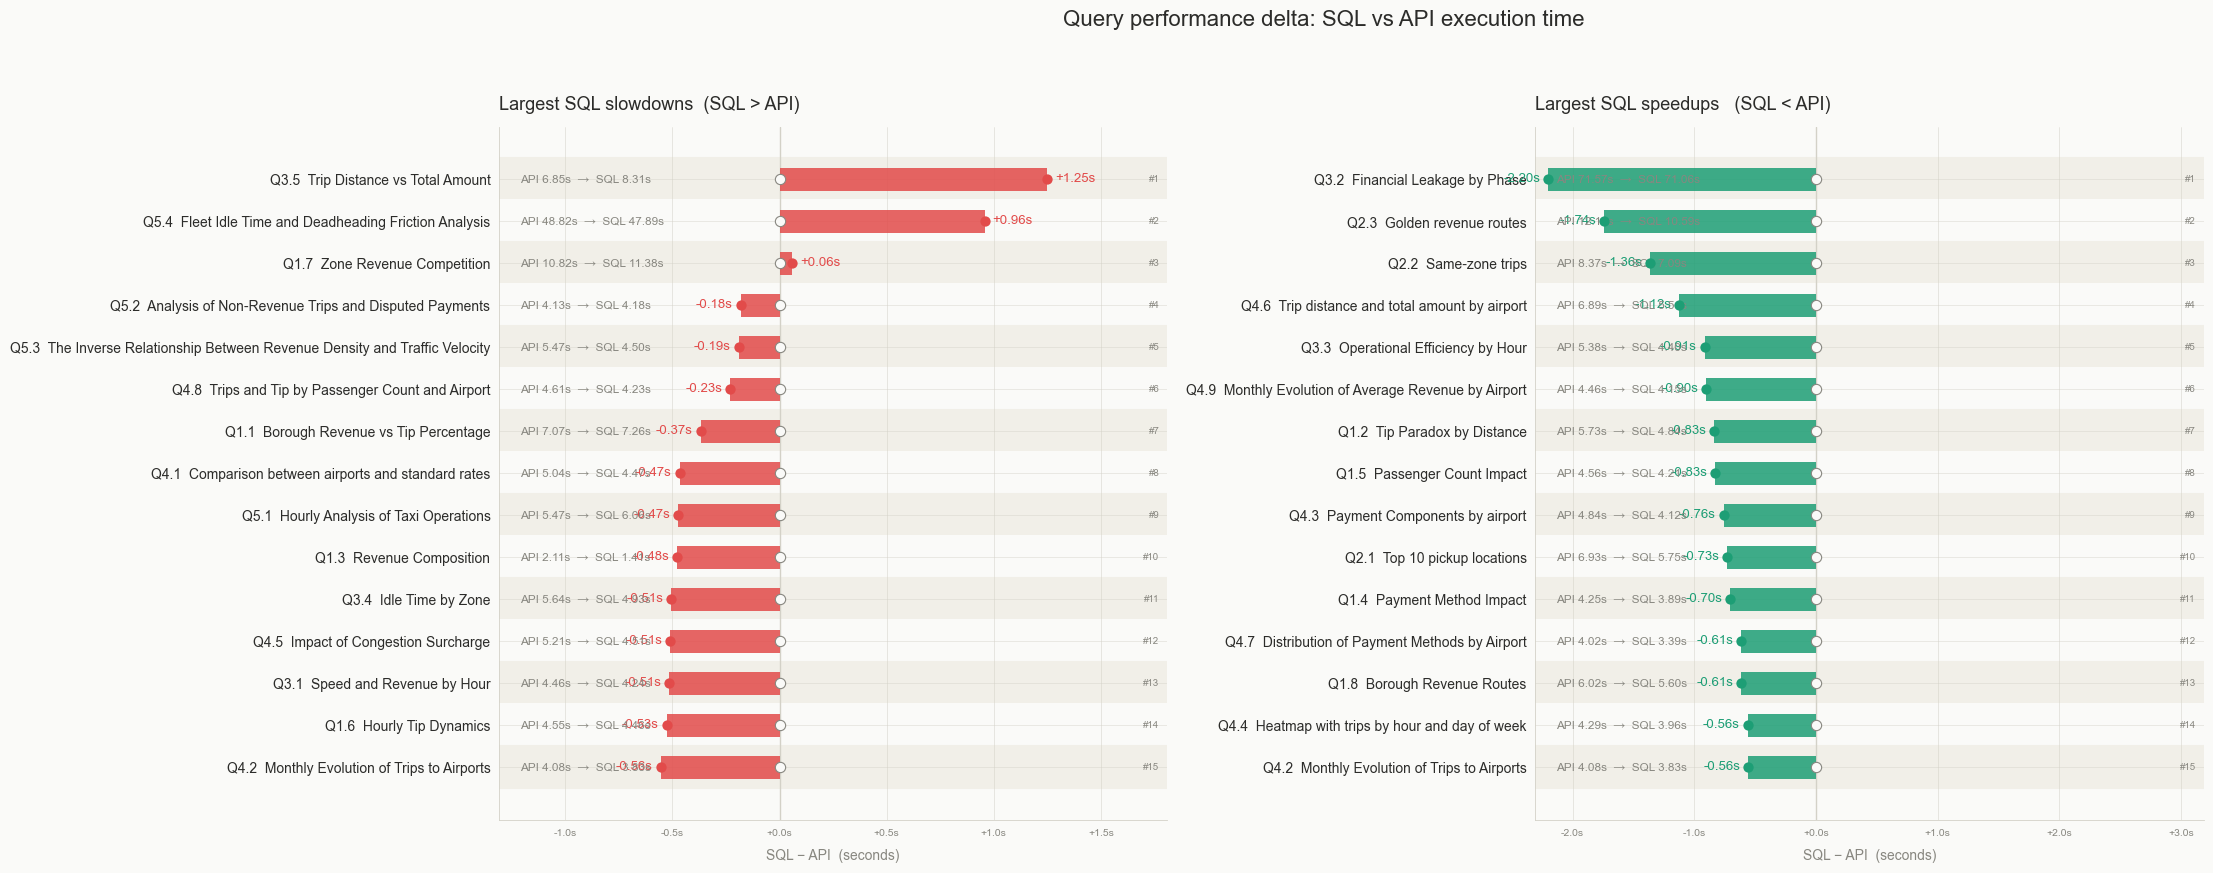

In [28]:
ranked   = per_query.copy().sort_values('median_delta_s', ascending=False)
top_slow = ranked.head(15).copy()
top_fast = ranked.tail(15).sort_values('median_delta_s').copy()

import numpy as np
import matplotlib.ticker as mticker

BG      = "#FAFAF8"
SURFACE = "#F1EFE8"
BORDER  = "#D3D1C7"
TEXT    = "#2C2C2A"
TEXT_M  = "#888780"
RED     = "#E24B4A"
RED_L   = "#FCEBEB"
GREEN   = "#1D9E75"
GREEN_L = "#E1F5EE"

def diverging_panel(ax, subset, title, mode):
    """
    mode = 'slow'  → bars go right (SQL slower, positive delta)
    mode = 'fast'  → bars go left  (SQL faster, negative delta)
    """
    subset = subset.reset_index(drop=True)
    n = len(subset)
    labels = subset["query_description"].str.replace(r"^(Q\d+\.\d+):\s*", r"\1  ", regex=True)
    deltas = subset["median_delta_s"].values          # SQL - API
    api_v  = subset["median_api_s"].values
    sql_v  = subset["median_sql_s"].values

    col    = RED   if mode == "slow" else GREEN
    col_l  = RED_L if mode == "slow" else GREEN_L
    y      = np.arange(n)

    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
        spine.set_linewidth(0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # alternating row bands
    for i in range(n):
        ax.axhspan(i - 0.5, i + 0.5,
                   color=SURFACE if i % 2 == 0 else BG, zorder=0)

    # zero line
    ax.axvline(0, color=BORDER, linewidth=1.0, zorder=1)

    # bars
    ax.barh(y, deltas, height=0.55, color=col, alpha=0.85,
            zorder=2, linewidth=0)

    # API dot  (circle, hollow)
    ax.scatter(np.zeros(n), y, s=55, facecolors=BG,
               edgecolors=TEXT_M, linewidths=0.8, zorder=4, label="API median")

    # SQL dot  (filled)
    ax.scatter(deltas, y, s=55, color=col,
               zorder=5, linewidths=0, label="SQL median")

    # value labels — time values at bar tip
    for i, (d, a, s) in enumerate(zip(deltas, api_v, sql_v)):
        sign = "+" if d >= 0 else ""
        pad  = abs(deltas).max() * 0.03
        ha   = "left" if d >= 0 else "right"
        x    = d + (pad if d >= 0 else -pad)
        ax.text(x, i, f"{sign}{d:.2f}s",
                va="center", ha=ha, fontsize=9.5,
                color=col, fontweight="medium")
        # small API / SQL time in muted text inside row
        ax.text(-abs(deltas).max() * 0.97, i,
                f"API {a:.2f}s  →  SQL {s:.2f}s",
                va="center", ha="left", fontsize=8.5, color=TEXT_M)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10, color=TEXT)
    ax.tick_params(axis="y", length=0, pad=6)
    ax.tick_params(axis="x", labelsize=7.5, color=TEXT_M, labelcolor=TEXT_M, length=3)
    ax.set_xlim(-abs(deltas).max() * 1.05, abs(deltas).max() * 1.45)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}s"))
    ax.set_xlabel("SQL − API  (seconds)", fontsize=10, color=TEXT_M, labelpad=8)
    ax.set_title(title, fontsize=13, fontweight="medium", color=TEXT, pad=12, loc="left")
    ax.invert_yaxis()
    ax.grid(axis="x", color=BORDER, linewidth=0.5, alpha=0.7, zorder=0)

    # rank numbers
    for i in range(n):
        ax.text(abs(deltas).max() * 1.42, i, f"#{i+1}",
                va="center", ha="right", fontsize=7, color=TEXT_M)

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(22, 9),
    facecolor=BG,
    gridspec_kw={"wspace": 0.55}
)

diverging_panel(ax_l, top_slow, "Largest SQL slowdowns  (SQL > API)", mode="slow")
diverging_panel(ax_r, top_fast, "Largest SQL speedups   (SQL < API)", mode="fast")

plt.suptitle("Query performance delta: SQL vs API execution time",
             fontsize=16, fontweight="medium", color=TEXT, y=1.01)
plt.show()

## Models Analysis

In [12]:
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Derived columns ───────────────────────────────────────────────────────────
df_models["executor_memory_gb"] = (
    df_models["executor_memory"]
    .fillna("0g")
    .str.replace("g", "", regex=False)
    .astype(int)
)
df_models["total_cores"]    = df_models["executor_instances"] * df_models["executor_cores"]
df_models["resource_score"] = df_models["total_cores"] * df_models["executor_memory_gb"]

MODE_ORDER = [
    "baseline", "balanced", "high_parallelism", "memory_optimized",
    "stress_test", "low_overhead", "aqe_only", "cpu_heavy",
]
SHORT = {
    "baseline": "baseline", "balanced": "balanced",
    "high_parallelism": "hi_parallel", "memory_optimized": "mem_opt",
    "stress_test": "stress", "low_overhead": "low_ovhd",
    "aqe_only": "aqe_only", "cpu_heavy": "cpu_heavy",
}

# Keep only modes present in the data
MODE_ORDER = [m for m in MODE_ORDER if m in df_models["spark_mode"].unique()]
xlabels = [SHORT.get(m, m) for m in MODE_ORDER]
x = np.arange(len(MODE_ORDER))

# Per-target slices, aggregated per spark_mode to avoid duplicate-index reindex errors
df_amt = (
    df_models[df_models["target"] == "total_amount"]
    .groupby("spark_mode", observed=True, as_index=False)
    .agg(
        r2=("r2", "median"),
        rmse=("rmse", "median"),
        mae=("mae", "median"),
        mse=("mse", "median"),
        execution_time_seconds=("execution_time_seconds", "median"),
        executor_instances=("executor_instances", "first"),
        executor_cores=("executor_cores", "first"),
        executor_memory_gb=("executor_memory_gb", "first"),
        shuffle_partitions=("shuffle_partitions", "first"),
        adaptive=("adaptive", "first"),
    )
    .set_index("spark_mode")
    .reindex(MODE_ORDER)
    .reset_index()
)

df_dur = (
    df_models[df_models["target"] == "trip_duration_min"]
    .groupby("spark_mode", observed=True, as_index=False)
    .agg(
        r2=("r2", "median"),
        rmse=("rmse", "median"),
        mae=("mae", "median"),
        mse=("mse", "median"),
        execution_time_seconds=("execution_time_seconds", "median"),
        executor_instances=("executor_instances", "first"),
        executor_cores=("executor_cores", "first"),
        executor_memory_gb=("executor_memory_gb", "first"),
        shuffle_partitions=("shuffle_partitions", "first"),
        adaptive=("adaptive", "first"),
    )
    .set_index("spark_mode")
    .reindex(MODE_ORDER)
    .reset_index()
)

# Per-run totals (sum of both models)
df_run = (
    df_models.groupby("spark_mode")
    .agg(
        total_time         = ("execution_time_seconds", "sum"),
        executor_instances = ("executor_instances",     "first"),
        executor_cores     = ("executor_cores",         "first"),
        executor_memory_gb = ("executor_memory_gb",     "first"),
        shuffle_partitions = ("shuffle_partitions",     "first"),
        adaptive           = ("adaptive",               "first"),
        total_cores        = ("total_cores",            "first"),
        resource_score     = ("resource_score",         "first"),
    )
    .reindex(MODE_ORDER)
    .reset_index()
)
print("Prep complete — modes:", MODE_ORDER)


Prep complete — modes: ['baseline', 'balanced', 'high_parallelism', 'memory_optimized', 'stress_test', 'low_overhead', 'aqe_only', 'cpu_heavy']


In [13]:
BG       = "#FAFAF8"
SURFACE  = "#F1EFE8"
TEXT     = "#2C2C2A"
TEXT_MUT = "#888780"
BORDER   = "#D3D1C7"
BLUE     = "#378ADD"
TEAL     = "#1D9E75"
PURPLE   = "#7F77DD"
CORAL    = "#D85A30"
AMBER    = "#BA7517"
GREEN    = "#639922"
RED      = "#E24B4A"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT_MUT,
    "axes.labelsize":    9,
    "axes.titlesize":    11,
    "axes.titleweight":  "medium",
    "axes.titlecolor":   TEXT,
    "axes.titlepad":     10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        BORDER,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.6,
    "xtick.color":       TEXT_MUT,
    "ytick.color":       TEXT_MUT,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "legend.frameon":    False,
})

def bar_mean_line(ax, x, values, color, width=0.55):
    ax.bar(x, values, width=width, color=color, alpha=0.88, linewidth=0, zorder=3)
    mean_val = np.nanmean(values)
    ax.axhline(mean_val, color=color, linewidth=1.4, linestyle="--", alpha=0.7, zorder=4)
    ax.text(x[-1] + 0.55, mean_val, f"mean\n{mean_val:.4f}",
            va="center", ha="left", fontsize=7, color=color)

def style_ax(ax, title, xlabel="", ylabel="", xticks=None, xlabels_=None):
    ax.set_title(title, pad=8)
    if xlabel:   ax.set_xlabel(xlabel, labelpad=6)
    if ylabel:   ax.set_ylabel(ylabel, labelpad=6)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels_ or xticks, rotation=35, ha="right", fontsize=8)
    ax.tick_params(length=0)

def insight_box(ax, title, value, body, color):
    ax.set_facecolor(color + "22")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.text(0.5, 0.85, title, ha="center", va="top", fontsize=7.5,
            color=TEXT_MUT, transform=ax.transAxes, fontweight="medium")
    ax.text(0.5, 0.58, value, ha="center", va="top", fontsize=13,
            color=TEXT,     transform=ax.transAxes, fontweight="medium")
    ax.text(0.5, 0.34, body,  ha="center", va="top", fontsize=7,
            color=TEXT_MUT, transform=ax.transAxes, multialignment="center")
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(1.2); sp.set_visible(True)

print("Helpers ready.")

Helpers ready.


## KPI Summary

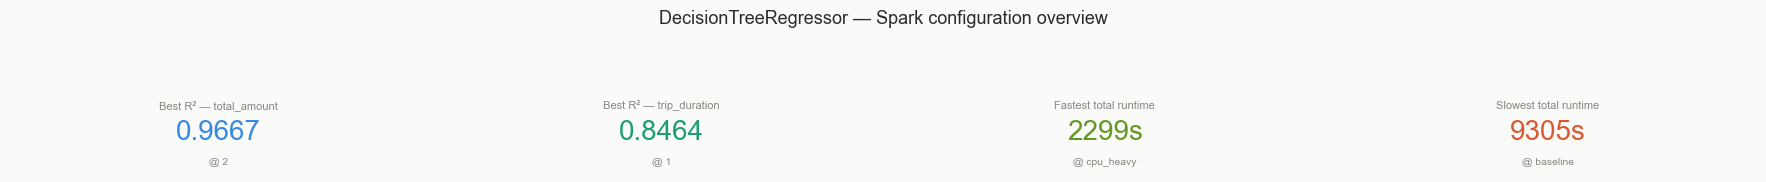

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 1.8), facecolor=BG)
fig.suptitle("DecisionTreeRegressor — Spark configuration overview",
             fontsize=13, fontweight="medium", color=TEXT, y=1.05)

kpis = [
    ("Best R² — total_amount",  f"{df_amt['r2'].max():.4f}",  f"@ {df_amt['r2'].idxmax()}",              BLUE),
    ("Best R² — trip_duration", f"{df_dur['r2'].max():.4f}",  f"@ {df_dur['r2'].idxmax()}",              TEAL),
    ("Fastest total runtime",
     f"{df_run['total_time'].min():.0f}s",
     f"@ {df_run.loc[df_run['total_time'].idxmin(), 'spark_mode']}",                                      GREEN),
    ("Slowest total runtime",
     f"{df_run['total_time'].max():.0f}s",
     f"@ {df_run.loc[df_run['total_time'].idxmax(), 'spark_mode']}",                                      CORAL),
]
for ax, (label, val, sub, col) in zip(axes, kpis):
    ax.set_facecolor(SURFACE); ax.axis("off")
    ax.text(0.5, 0.82, label, ha="center", va="center", fontsize=8,
            color=TEXT_MUT, transform=ax.transAxes)
    ax.text(0.5, 0.48, val,   ha="center", va="center", fontsize=20,
            color=col,      transform=ax.transAxes, fontweight="medium")
    ax.text(0.5, 0.12, sub,   ha="center", va="center", fontsize=7.5,
            color=TEXT_MUT, transform=ax.transAxes)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER); sp.set_visible(True)

plt.tight_layout()
plt.show()

## R² per Spark configuration

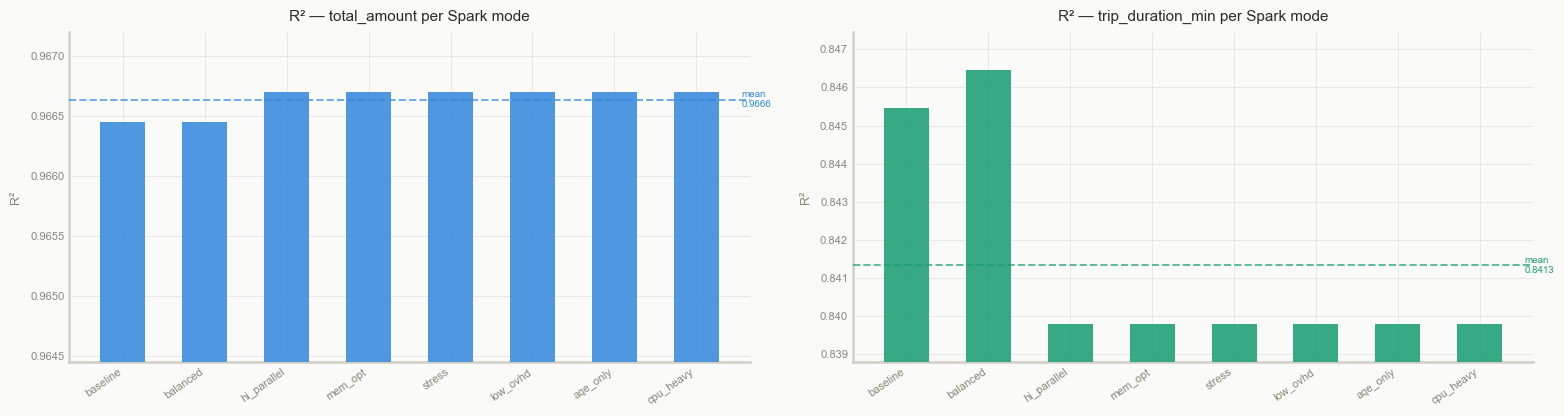

In [31]:
fig, (ax_a, ax_d) = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)

bar_mean_line(ax_a, x, df_amt["r2"].values, BLUE)
style_ax(ax_a, "R² — total_amount per Spark mode",
         ylabel="R²", xticks=x, xlabels_=xlabels)
ax_a.set_ylim(df_amt["r2"].min() - 0.002, df_amt["r2"].max() + 0.0005)

bar_mean_line(ax_d, x, df_dur["r2"].values, TEAL)
style_ax(ax_d, "R² — trip_duration_min per Spark mode",
         ylabel="R²", xticks=x, xlabels_=xlabels)
ax_d.set_ylim(df_dur["r2"].min() - 0.001, df_dur["r2"].max() + 0.001)

plt.tight_layout()
plt.show()

## Execution time & MAE

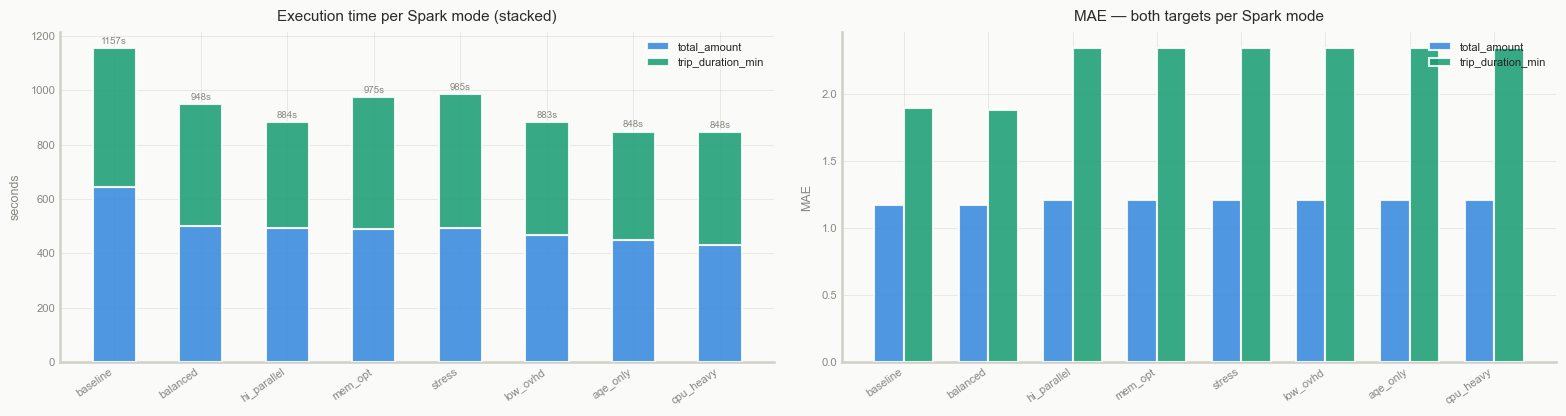

In [16]:
fig, (ax_t, ax_m) = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)

# Stacked execution time
w = 0.5
amt_times = df_amt["execution_time_seconds"].values
dur_times = df_dur["execution_time_seconds"].values
ax_t.bar(x, amt_times, width=w, color=BLUE,  alpha=0.88, label="total_amount",     zorder=3)
ax_t.bar(x, dur_times, width=w, color=TEAL,  alpha=0.88, label="trip_duration_min",
         bottom=amt_times, zorder=3)
for i_, (ta, td) in enumerate(zip(amt_times, dur_times)):
    ax_t.text(i_, ta + td + 8, f"{ta+td:.0f}s",
              ha="center", va="bottom", fontsize=7, color=TEXT_MUT)
style_ax(ax_t, "Execution time per Spark mode (stacked)",
         ylabel="seconds", xticks=x, xlabels_=xlabels)
ax_t.legend(loc="upper right")

# Grouped MAE
w2 = 0.35
ax_m.bar(x - w2/2, df_amt["mae"].values, width=w2, color=BLUE, alpha=0.88,
         label="total_amount",     zorder=3)
ax_m.bar(x + w2/2, df_dur["mae"].values, width=w2, color=TEAL, alpha=0.88,
         label="trip_duration_min", zorder=3)
style_ax(ax_m, "MAE — both targets per Spark mode",
         ylabel="MAE", xticks=x, xlabels_=xlabels)
ax_m.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Quality vs speed tradeoff

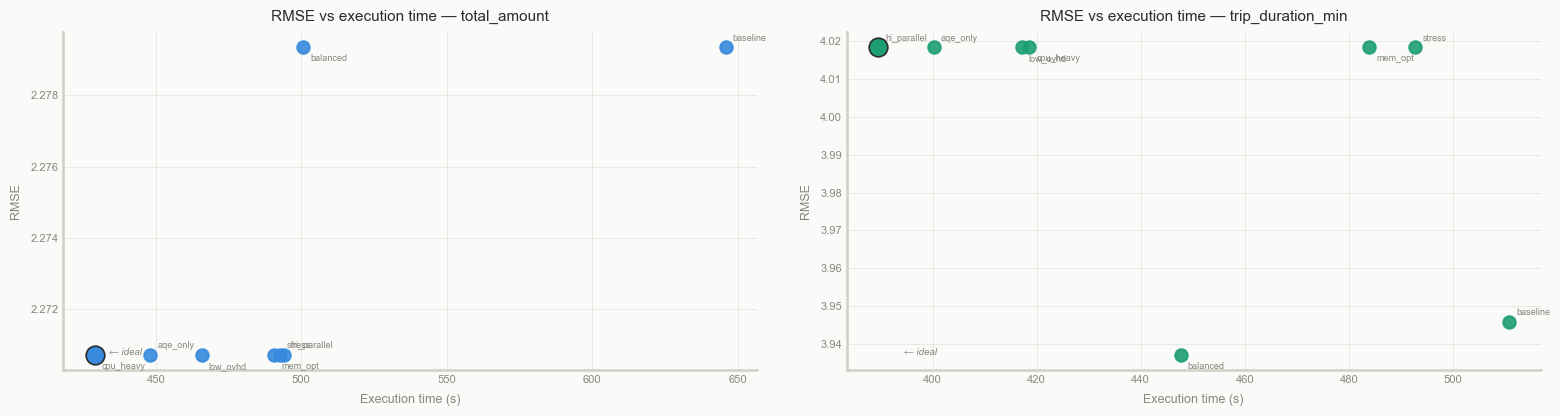

In [17]:
fig, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)

for ax_sc, df_t, target, color in [
    (ax_s1, df_amt, "total_amount",      BLUE),
    (ax_s2, df_dur, "trip_duration_min", TEAL),
]:
    times = df_t["execution_time_seconds"].values
    rmses = df_t["rmse"].values
    ax_sc.scatter(times, rmses, color=color, s=80, zorder=5, alpha=0.9)
    for i_, (m, t, r) in enumerate(zip(MODE_ORDER, times, rmses)):
        offset = (5, 5) if i_ % 2 == 0 else (5, -10)
        ax_sc.annotate(SHORT.get(m, m), (t, r), fontsize=6.5, color=TEXT_MUT,
                       xytext=offset, textcoords="offset points")
    best_i = int(np.nanargmin(rmses + times / np.nanmax(times)))
    ax_sc.scatter(times[best_i], rmses[best_i], color=color, s=180,
                  zorder=6, edgecolors=TEXT, linewidths=1.2)
    style_ax(ax_sc, f"RMSE vs execution time — {target}",
             xlabel="Execution time (s)", ylabel="RMSE")
    ax_sc.annotate("← ideal", xy=(np.nanmin(times) + 5, np.nanmin(rmses)),
                   fontsize=7, color=TEXT_MUT, style="italic")

plt.tight_layout()
plt.show()

## AQE impact & resource allocation

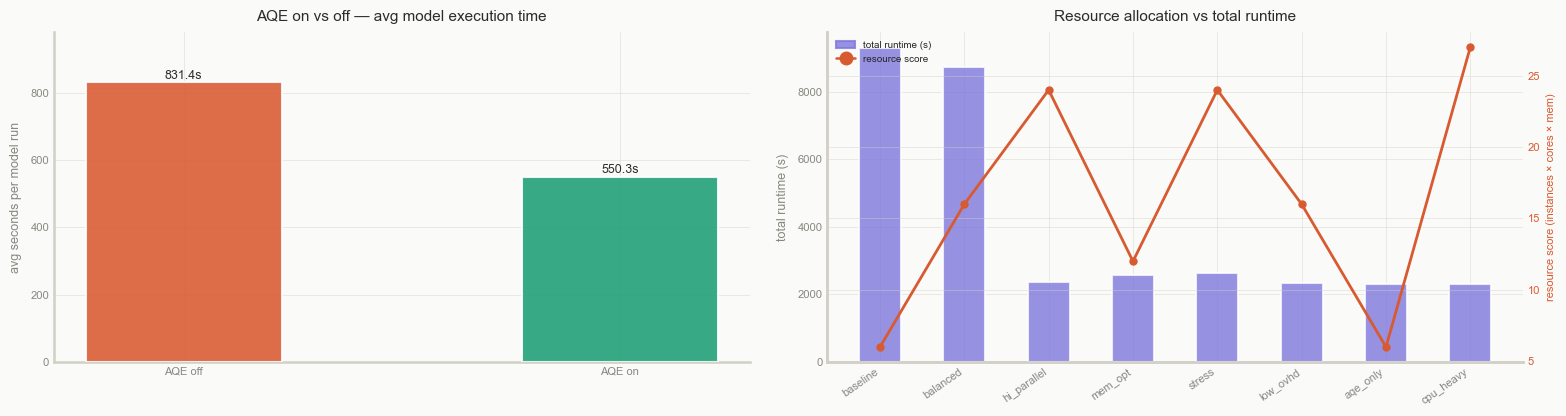

In [18]:
fig, (ax_aqe, ax_res) = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)

# AQE on vs off
aqe_on  = df_models[df_models["adaptive"] == True]["execution_time_seconds"].mean()
aqe_off = df_models[df_models["adaptive"] == False]["execution_time_seconds"].mean()
bars = ax_aqe.bar(["AQE off", "AQE on"], [aqe_off, aqe_on],
                  color=[CORAL, TEAL], width=0.45, alpha=0.88, zorder=3)
for bar_, val in zip(bars, [aqe_off, aqe_on]):
    ax_aqe.text(bar_.get_x() + bar_.get_width() / 2,
                bar_.get_height() + 2, f"{val:.1f}s",
                ha="center", va="bottom", fontsize=9, fontweight="medium", color=TEXT)
style_ax(ax_aqe, "AQE on vs off — avg model execution time",
         ylabel="avg seconds per model run")
ax_aqe.set_ylim(0, max(aqe_off, aqe_on) * 1.18)

# Resource score vs runtime (dual axis)
res_scores  = df_run["resource_score"].values
total_times = df_run["total_time"].values
ax_res.bar(x, total_times, width=0.5, color=PURPLE, alpha=0.80, zorder=3)
ax2 = ax_res.twinx()
ax2.plot(x, res_scores, color=CORAL, linewidth=2, marker="o",
         markersize=5, zorder=5)
ax2.set_ylabel("resource score (instances × cores × mem)", color=CORAL, fontsize=8)
ax2.tick_params(axis="y", labelcolor=CORAL, labelsize=8, length=0)
ax2.spines["right"].set_edgecolor(CORAL)
ax2.spines["top"].set_visible(False)
style_ax(ax_res, "Resource allocation vs total runtime",
         ylabel="total runtime (s)", xticks=x, xlabels_=xlabels)
handles = [
    mpatches.Patch(color=PURPLE, alpha=0.80, label="total runtime (s)"),
    Line2D([0], [0], color=CORAL, marker="o", linewidth=1.8,
           label="resource score"),
]
ax_res.legend(handles=handles, loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()